Please upload your 'Motorcycle_crash_data.xlsx' file:


Saving Motorcycle_crash_data.xlsx to Motorcycle_crash_data.xlsx

Data loaded successfully! Beginning construction...

Engine starting... Training on 80% of data...
Training complete!

Training Set Accuracy: 80.20%
--- FINAL RESULTS ---
Final Training Cost: 0.4228
Test Set Accuracy: 81.30%



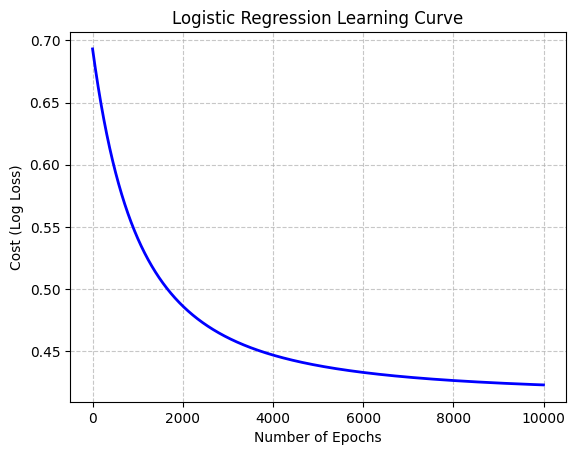

In [ ]:

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Please upload your 'Motorcycle_crash_data.xlsx' file:")
uploaded = files.upload()

df = pd.read_excel('Motorcycle_crash_data.xlsx')
print("\nData loaded successfully! Beginning construction...\n")

df['y_target'] = df['severity'].map({'Minor': 0, 'Moderate': 0, 'Severe': 1, 'Fatal': 1})
df['helmet_binary'] = df['helmet_worn'].map({'No': 0, 'Partial': 0, 'Yes': 1})
df['gender_binary'] = df['rider_gender'].map({'Female': 0, 'Male': 1})

df_encoded = pd.get_dummies(df, columns=['road_type', 'road_condition', 'alcohol_influence'], dtype=int)

df_final = df_encoded.drop(columns=['severity', 'helmet_worn', 'rider_gender'])

y = df_final['y_target'].values
x = df_final.drop(columns=['y_target']).values
m, n = x.shape

x[:, 0] = (x[:, 0] - np.mean(x[:, 0])) / np.std(x[:, 0])
x[:, 1] = (x[:, 1] - np.mean(x[:, 1])) / np.std(x[:, 1])

np.random.seed(42)
indices = np.arange(m)
np.random.shuffle(indices)

split_idx = int(m * 0.8)
x_train, x_test = x[indices[:split_idx]], x[indices[split_idx:]]
y_train, y_test = y[indices[:split_idx]], y[indices[split_idx:]]

m_train = x_train.shape[0]

w = np.zeros(n)
b = 0.0
alpha = 0.01
epochs = 10000
cost_history = []

print("Engine starting... Training on 80% of data...")

for i in range(epochs):
    z = np.dot(x_train, w) + b
    y_hat = 1 / (1 + np.exp(-z))

    cost = -(1/m_train) * np.sum(y_train * np.log(y_hat) + (1 - y_train) * np.log(1 - y_hat))
    cost_history.append(cost)

    error = y_hat - y_train
    dw = (1/m_train) * np.dot(x_train.T, error)
    db = (1/m_train) * np.sum(error)

    w = w - (alpha * dw)
    b = b - (alpha * db)

print("Training complete!\n")

z_test = np.dot(x_test, w) + b
y_hat_test = 1 / (1 + np.exp(-z_test))
predictions = (y_hat_test >= 0.5).astype(int)
z_train = np.dot(x_train, w) + b
y_hat_train = 1 / (1 + np.exp(-z_train))
predictions_train = (y_hat_train >= 0.5).astype(int)

train_accuracy = np.mean(predictions_train == y_train)
print(f"Training Set Accuracy: {train_accuracy * 100:.2f}%")
accuracy = np.mean(predictions == y_test)
print(f"--- FINAL RESULTS ---")
print(f"Final Training Cost: {cost_history[-1]:.4f}")
print(f"Test Set Accuracy: {accuracy * 100:.2f}%\n")

plt.plot(range(epochs), cost_history, color='blue', linewidth=2)
plt.title('Logistic Regression Learning Curve')
plt.xlabel('Number of Epochs')
plt.ylabel('Cost (Log Loss)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Experiment: Feature Importance & Polynomial Boundaries

Waiting for materials... Please upload 'Motorcycle_crash_data.xlsx':


Saving Motorcycle_crash_data.xlsx to Motorcycle_crash_data.xlsx

Data received! Booting up the Polynomial Engine...

--- THE AUTOPSY (POLYNOMIAL ENGINE) ---
Weight 1 (X1):      0.7702
Weight 2 (X2):      -0.1109
Weight 3 (X1^2):    0.1360
Weight 4 (X2^2):    0.1003
Weight 5 (X1*X2):   -0.0236
Bias (b):           0.0596
Train Accuracy:     59.27%
Test Accuracy:      64.50%



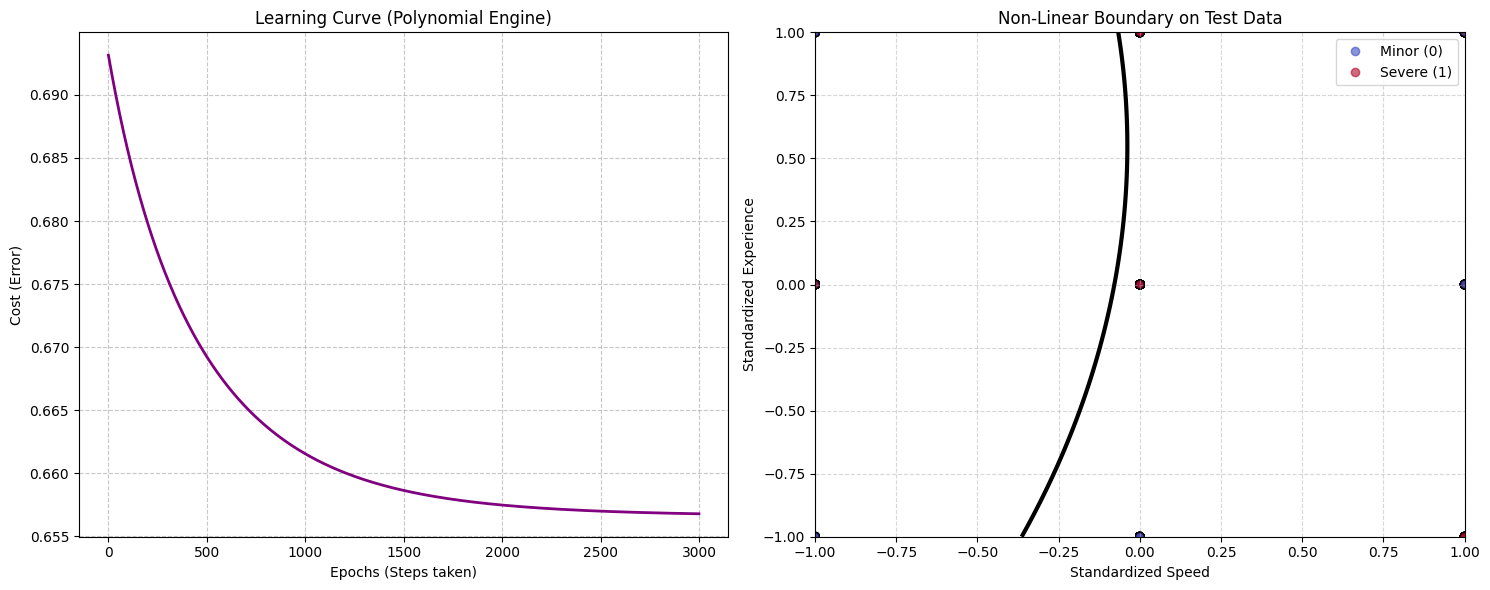

In [4]:
# --- 1. UPLOAD AND IMPORT ---
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Waiting for materials... Please upload 'Motorcycle_crash_data.xlsx':")
uploaded = files.upload()
print("\nData received! Booting up the Polynomial Engine...\n")

# --- 2. LOAD & ISOLATE ---
df = pd.read_excel('Motorcycle_crash_data.xlsx')
df['y_target'] = df['severity'].map({'Minor': 0, 'Moderate': 0, 'Severe': 1, 'Fatal': 1})

# Extract the base features
x_base = df[['speed_kmh', 'rider_experience_years']].values
y = df['y_target'].values
m = x_base.shape[0]

# --- 3. SCALING (Z-Score Normalization) ---
x_base[:, 0] = (x_base[:, 0] - np.mean(x_base[:, 0])) / np.std(x_base[:, 0])
x_base[:, 1] = (x_base[:, 1] - np.mean(x_base[:, 1])) / np.std(x_base[:, 1])

# --- 4. POLYNOMIAL FEATURE EXPANSION ---
# We synthesize the new columns: X1, X2, X1^2, X2^2, X1*X2
X1 = x_base[:, 0]
X2 = x_base[:, 1]

# np.column_stack glues these individual arrays into one large matrix
x_poly = np.column_stack((X1, X2, X1**2, X2**2, X1 * X2))
n_poly = x_poly.shape[1] # This is now 5!

# --- 5. THE 80/20 TRAIN/TEST SPLIT ---
np.random.seed(42)
indices = np.arange(m)
np.random.shuffle(indices)

split_idx = int(m * 0.8)
x_train, x_test = x_poly[indices[:split_idx]], x_poly[indices[split_idx:]]
y_train, y_test = y[indices[:split_idx]], y[indices[split_idx:]]

m_train = x_train.shape[0]

# --- 6. INITIALIZE THE CUSTOM ENGINE ---
w = np.zeros(n_poly)  # The engine now automatically creates 5 weights!
b = 0.0
alpha = 0.01
epochs = 3000    # Adding a bit more time for the complex curve to settle
cost_history = []

# --- 7. THE TRAINING LOOP ---
for i in range(epochs):
    z = np.dot(x_train, w) + b
    y_hat = 1 / (1 + np.exp(-z))

    cost = -(1/m_train) * np.sum(y_train * np.log(y_hat) + (1 - y_train) * np.log(1 - y_hat))
    cost_history.append(cost)

    error = y_hat - y_train
    dw = (1/m_train) * np.dot(x_train.T, error)
    db = (1/m_train) * np.sum(error)

    w = w - (alpha * dw)
    b = b - (alpha * db)

# --- 8. THE AUTOPSY & DIAGNOSTICS ---
z_train = np.dot(x_train, w) + b
train_acc = np.mean(((1 / (1 + np.exp(-z_train))) >= 0.5).astype(int) == y_train)

z_test = np.dot(x_test, w) + b
test_acc = np.mean(((1 / (1 + np.exp(-z_test))) >= 0.5).astype(int) == y_test)

print("--- THE AUTOPSY (POLYNOMIAL ENGINE) ---")
print(f"Weight 1 (X1):      {w[0]:.4f}")
print(f"Weight 2 (X2):      {w[1]:.4f}")
print(f"Weight 3 (X1^2):    {w[2]:.4f}")
print(f"Weight 4 (X2^2):    {w[3]:.4f}")
print(f"Weight 5 (X1*X2):   {w[4]:.4f}")
print(f"Bias (b):           {b:.4f}")
print(f"Train Accuracy:     {train_acc * 100:.2f}%")
print(f"Test Accuracy:      {test_acc * 100:.2f}%\n")

# --- 9. THE DUAL-MONITOR DASHBOARD ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Monitor 1: The Learning Curve
ax1.plot(range(epochs), cost_history, color='purple', linewidth=2)
ax1.set_title('Learning Curve (Polynomial Engine)')
ax1.set_xlabel('Epochs (Steps taken)')
ax1.set_ylabel('Cost (Error)')
ax1.grid(True, linestyle='--', alpha=0.7)

# Monitor 2: The Non-Linear Decision Boundary
# To draw curves, we map every pixel on the graph and test its probability
xx, yy = np.meshgrid(np.linspace(X1.min(), X1.max(), 100),
                     np.linspace(X2.min(), X2.max(), 100))

# We synthesize the grid points just like we did the training data
grid_poly = np.c_[xx.ravel(), yy.ravel(), xx.ravel()**2, yy.ravel()**2, xx.ravel()*yy.ravel()]
Z_grid = np.dot(grid_poly, w) + b
probs = 1 / (1 + np.exp(-Z_grid))
probs = probs.reshape(xx.shape)

# Plot the test data
scatter = ax2.scatter(X1[indices[split_idx:]], X2[indices[split_idx:]],
                      c=y_test, cmap='coolwarm', edgecolors='k', alpha=0.6)

# Draw the 50% probability contour line
ax2.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=3)

ax2.set_title('Non-Linear Boundary on Test Data')
ax2.set_xlabel('Standardized Speed')
ax2.set_ylabel('Standardized Experience')
ax2.legend(handles=scatter.legend_elements()[0], labels=['Minor (0)', 'Severe (1)'])
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()